<a href="https://colab.research.google.com/github/naikwadesharvil/mental-health-detection-nlp/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required libraries
!pip install transformers datasets torch scikit-learn
!pip install lime shap wandb
!pip install pandas numpy matplotlib seaborn
!pip install nltk emoji contractions

print("✅ All libraries installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=e11c32e8ecead97a9d47da309d90b461c07d9e6b318ab1b35e9c5dafc20fe88d
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.1 MB/s eta 0:00:00
✅ All libraries installed successfully!


In [2]:
import torch

print("🔍 Checking GPU Availability...")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"CUDA Device Count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print("\n✅ Setup verification complete!")

🔍 Checking GPU Availability...
CUDA Available: True
CUDA Device Count: 1
GPU Name: Tesla T4
GPU Memory: 15.64 GB

✅ Setup verification complete!


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully! 🚀")

url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"
df = pd.read_csv(url)

print(df.head())
print(df.columns)

# Load the dataset using Pandas
df = pd.read_csv(url)

# Let's rename the columns to make them easier to work with
df = df.rename(columns={'message to examine': 'text', 'label (depression result)': 'label'})

# Drop the index column as we don't need it
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(f"Dataset loaded! We have {df.shape[0]} rows and {df.shape[1]} columns.")
display(df.head()) # This will show the first 5 rows

Libraries imported successfully! 🚀
   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation
Index(['id', 'label', 'tweet'], dtype='object')
Dataset loaded! We have 31962 rows and 3 columns.


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


Missing values in each column:
 id       0
label    0
tweet    0
dtype: int64


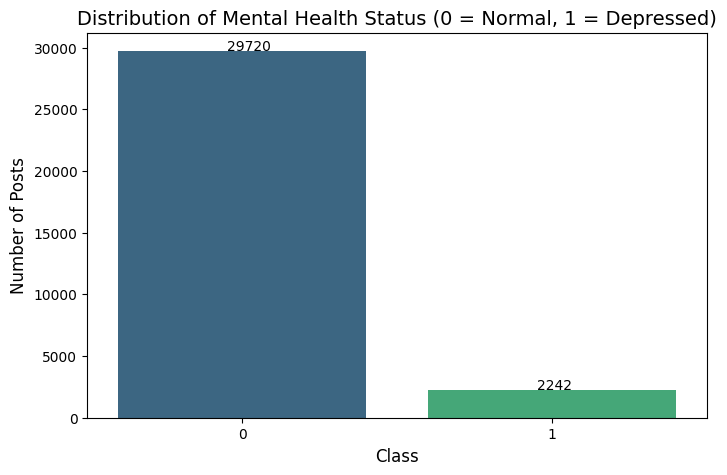

Normal Posts: 92.99%
Depressed Posts: 7.01%


In [9]:
# Check for missing values
print("Missing values in each column:\n", df.isnull().sum())

# Plot the distribution of our classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label', palette='viridis')
plt.title('Distribution of Mental Health Status (0 = Normal, 1 = Depressed)', fontsize=14)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Posts', fontsize=12)

# Add exact numbers on top of the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + 0.35, p.get_height() + 50))

plt.show()

# Calculate exact percentages
normal_pct = (df['label'] == 0).mean() * 100
dep_pct = (df['label'] == 1).mean() * 100
print(f"Normal Posts: {normal_pct:.2f}%")
print(f"Depressed Posts: {dep_pct:.2f}%")

In [14]:
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('wordnet')
import pandas as pd
import re
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

print(df.columns)

lemmatizer = WordNetLemmatizer()

def clean_text(text):
    if pd.isna(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]

    return ' '.join(words)

df['clean_text'] = df['tweet'].apply(clean_text)
print(df.head())

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Index(['id', 'label', 'tweet'], dtype='object')
   id  label                                              tweet  \
0   1      0   @user when a father is dysfunctional and is s...   
1   2      0  @user @user thanks for #lyft credit i can't us...   
2   3      0                                bihday your majesty   
3   4      0  #model   i love u take with u all the time in ...   
4   5      0             factsguide: society now    #motivation   

                                          clean_text  
0  father dysfunctional selfish drag kid dysfunct...  
1  thanks lyft credit cant use cause dont offer w...  
2                                     bihday majesty  
3                        model love u take u time ur  
4                      factsguide society motivation  


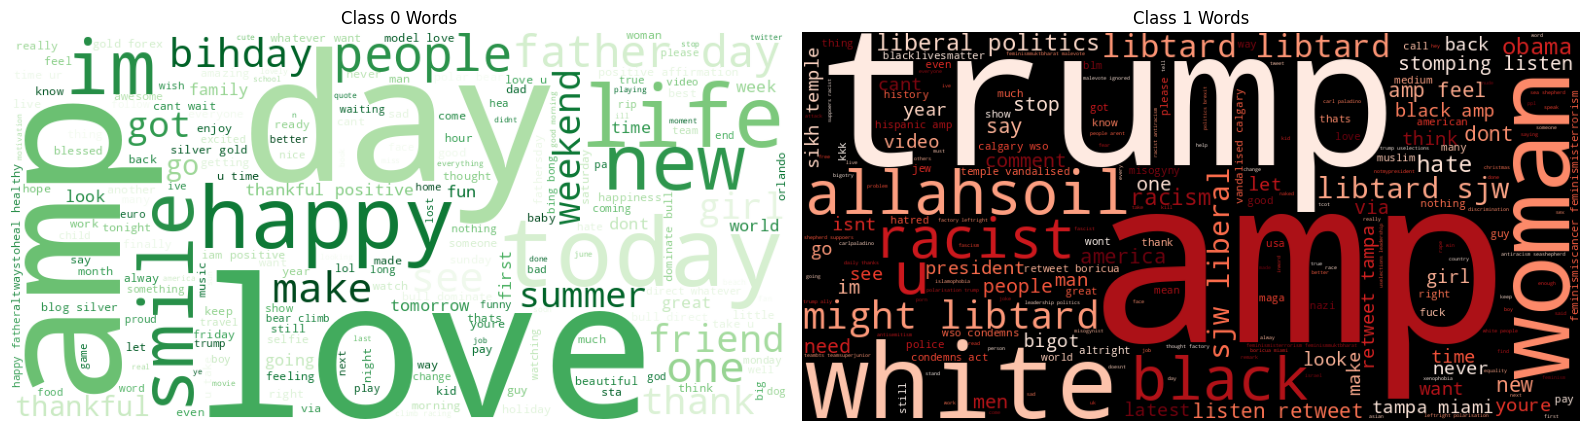

In [15]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Remove empty values
normal_df = df[(df['label'] == 0) & (df['clean_text'] != "")]
depressed_df = df[(df['label'] == 1) & (df['clean_text'] != "")]

normal_text = ' '.join(normal_df['clean_text'])
depressed_text = ' '.join(depressed_df['clean_text'])

plt.figure(figsize=(16, 8))

# Normal / Positive
plt.subplot(1, 2, 1)
if normal_text.strip():
    wc1 = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(normal_text)
    plt.imshow(wc1)
plt.title('Class 0 Words')
plt.axis('off')

# Depressed / Negative
plt.subplot(1, 2, 2)
if depressed_text.strip():
    wc2 = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(depressed_text)
    plt.imshow(wc2)
plt.title('Class 1 Words')
plt.axis('off')

plt.tight_layout()
plt.show()